# Task 3 — Predicting Gender and Occasion from Fashion Images

Given a photograph of a fashion item, predict two attributes: the **gender** it is intended for
and the **occasion** (`usage`) it suits.

## Approach

A convolutional neural network, trained from scratch on the 38,617-image catalogue. The network
follows the standard four-stage structure:

```
convolution  ->  non-linearity  ->  pooling  ->  fully-connected classifier
```

The first three stages extract features; the fourth turns those features into class scores. All
four are trained together by a single optimiser, so the convolutional filters are shaped by the
classification objective rather than by any separate criterion.

Because there are two attributes to predict, the network **branches early**: the first two
convolutional blocks are shared, then each attribute gets its own convolutional pathway and its
own classifier. The rationale is set out in Section 4.

## Structure of this notebook

| Part | Contents |
|---|---|
| 1 | Data, labels, baselines, and the train/validation/test split |
| 2 | The four stages, and the reasoning behind every design choice |
| 3 | Architecture selection, and the network definition |
| 4 | **Training the model** |
| 5 | Verifying the three design choices that were open to question |
| 6 | Addressing class imbalance |
| 7 | Final model, specification, and test results |

Parts 2 and 3 are analysis; Part 4 is where the model is actually built. Parts 5 and 6 are
controlled experiments that change one factor at a time.

## Evaluation

`usage` is 77% `Casual`, so accuracy alone is misleading — a constant predictor reaches that
figure without learning anything. **Macro-F1** is the primary metric because it weights every
class equally. Exact-match accuracy, where both attributes must be correct, is reported as the
product-level measure. All comparisons are judged against the sampling error of the validation
set, computed in Part 7.

## Part 1 — Data

In [51]:
# ============================================
# CELL 1 - Environment
# ============================================

import os
import json
import time
import copy
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42


def set_seed(seed=RANDOM_STATE):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
PROCESSED_DIR = PROJECT_DIR / "A2_FashionDataset" / "processed"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "task3"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "image_width": 60, "image_height": 80, "channels": 3,
    "targets": ["gender", "usage"],
    "batch_size": 128,
    "max_epochs": 60,                 # a ceiling, not a target: early stopping ends
    "early_stopping_patience": 8,     # each run when it stops improving
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "num_workers": 0,                 # 0 required on Windows notebooks
    "test_fraction": 0.15, "val_fraction": 0.15,
    "group_column": "productDisplayName",
    "verify_epochs": 15,              # shortened runs for the design checks in Part 5
}
IMAGE_SIZE_PIL = (CONFIG["image_width"], CONFIG["image_height"])
IMAGE_SHAPE = (CONFIG["image_height"], CONFIG["image_width"], 3)
INPUT_SHAPE = (3, CONFIG["image_height"], CONFIG["image_width"])
print(json.dumps(CONFIG, indent=2))

PyTorch: 2.11.0+cu128 | device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
{
  "image_width": 60,
  "image_height": 80,
  "channels": 3,
  "targets": [
    "gender",
    "usage"
  ],
  "batch_size": 128,
  "max_epochs": 60,
  "early_stopping_patience": 8,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "num_workers": 0,
  "test_fraction": 0.15,
  "val_fraction": 0.15,
  "group_column": "productDisplayName",
  "verify_epochs": 15
}


### Labels

`gender` has five values and needs no adjustment. `usage` has eight, but four of them are
vanishingly rare: `Smart Casual` (55 items), `Travel` (25), `Party` (13) and `Home` (1). Classes
that small cannot be learned, and cannot be stratified across a split.

Each is merged into its nearest surviving class based on what the items actually are rather than
on the label text:

* `Smart Casual` — dominated by watches, shirts and shoes, all everyday items → **Casual**
* `Travel` — every row is a bag (backpacks, rucksacks, duffels) → **Casual**
* `Party` — dresses, clutches and heels, all occasion wear → **Formal**
* `Home` — a single cushion cover, not a fashion item → **removed**

Rows with a missing `usage` label are dropped rather than imputed: assigning them the majority
class would insert confidently wrong labels into the class the model is already biased towards.

In [52]:
# ============================================
# CELL 2 - Labels
# ============================================

data = pd.read_csv(PROCESSED_DIR / "clean_train_metadata.csv")
print("rows loaded:", len(data))

model_df = data[data["usage"].notna() & data["gender"].notna()].copy()
print(f"dropped {len(data) - len(model_df)} rows with a missing target")

USAGE_MERGE = {"Smart Casual": "Casual", "Travel": "Casual", "Party": "Formal"}
model_df = model_df[model_df["usage"] != "Home"].copy()
model_df["usage_label"] = model_df["usage"].replace(USAGE_MERGE)
model_df["gender_label"] = model_df["gender"]

from sklearn.preprocessing import LabelEncoder

encoders, class_names = {}, {}
for target in CONFIG["targets"]:
    encoder = LabelEncoder()
    model_df[target + "_y"] = encoder.fit_transform(model_df[target + "_label"].astype(str))
    encoders[target] = encoder
    class_names[target] = list(encoder.classes_)

NUM_CLASSES = {t: len(encoders[t].classes_) for t in CONFIG["targets"]}
model_df = model_df.reset_index(drop=True)

for target in CONFIG["targets"]:
    counts = model_df[target + "_label"].value_counts()
    print(f"\n{target}: {len(counts)} classes")
    display(pd.DataFrame({"count": counts,
                          "share %": (counts / len(model_df) * 100).round(1)}))

rows loaded: 38612
dropped 72 rows with a missing target

gender: 5 classes


,count,share %
gender_label,,
Men,20890,54.2
Women,14129,36.7
Unisex,2061,5.3
Boys,814,2.1
Girls,645,1.7



usage: 4 classes


,count,share %
usage_label,,
Casual,29716,77.1
Sports,3940,10.2
Ethnic,2570,6.7
Formal,2313,6.0


In [53]:
# ============================================
# CELL 3 - Baselines
# ============================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

BASELINE = {}
for target in CONFIG["targets"]:
    y = model_df[target + "_y"].values
    dummy = DummyClassifier(strategy="most_frequent").fit(np.zeros((len(y), 1)), y)
    pred = dummy.predict(np.zeros((len(y), 1)))
    BASELINE[target] = {"accuracy": accuracy_score(y, pred) * 100,
                        "macro_f1": f1_score(y, pred, average="macro", zero_division=0) * 100}
    print(f"{target:8s} majority class -> accuracy {BASELINE[target]['accuracy']:5.2f}%, "
          f"macro-F1 {BASELINE[target]['macro_f1']:5.2f}")

print("\nThe gap between these two columns is why macro-F1 is the primary metric:")
print("a constant predictor reaches 77% accuracy on usage but only 22 macro-F1.")

gender   majority class -> accuracy 54.20%, macro-F1 14.06
usage    majority class -> accuracy 77.11%, macro-F1 21.77

The gap between these two columns is why macro-F1 is the primary metric:
a constant predictor reaches 77% accuracy on usage but only 22 macro-F1.


### Splitting

The catalogue contains many near-identical photographs of the same product — over 15,000 rows
share a `productDisplayName` with another row. A random split would place copies of one item on
both sides, so the model could score well by recognising specific photographs.

The split is therefore **grouped by product name**, so every photograph of a product stays on
one side, and **stratified on the joint `gender × usage` label**, so both attributes keep their
class balance across the three partitions.

In [54]:
# ============================================
# CELL 4 - Train / validation / test split
# ============================================

from sklearn.model_selection import StratifiedGroupKFold

model_df["_strat"] = model_df["gender_label"] + "|" + model_df["usage_label"]
counts = model_df["_strat"].value_counts()
model_df.loc[model_df["_strat"].isin(counts[counts < 10].index), "_strat"] = "RARE"
groups = model_df[CONFIG["group_column"]].fillna(model_df["id"].astype(str))


def grouped_split(df, strat, grp, fraction, seed=RANDOM_STATE):
    splitter = StratifiedGroupKFold(n_splits=max(2, int(round(1 / fraction))),
                                    shuffle=True, random_state=seed)
    keep, hold = next(splitter.split(df, strat, grp))
    return df.iloc[keep], df.iloc[hold]


trainval_df, test_df = grouped_split(model_df, model_df["_strat"], groups,
                                     CONFIG["test_fraction"])
tv_groups = trainval_df[CONFIG["group_column"]].fillna(trainval_df["id"].astype(str))
train_df, val_df = grouped_split(trainval_df, trainval_df["_strat"], tv_groups,
                                 CONFIG["val_fraction"] / (1 - CONFIG["test_fraction"]))

for name, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"{name:11s} {len(part):>6,}")

for a, b, label in [(train_df, val_df, "train/val"), (train_df, test_df, "train/test"),
                    (val_df, test_df, "val/test")]:
    overlap = set(a[CONFIG["group_column"]].fillna("")) & set(b[CONFIG["group_column"]].fillna(""))
    assert not overlap, f"product leaked across {label}"
print("\nNo product appears in more than one partition.")

comparison = pd.DataFrame({
    "train %": train_df["usage_label"].value_counts(normalize=True) * 100,
    "val %": val_df["usage_label"].value_counts(normalize=True) * 100,
    "test %": test_df["usage_label"].value_counts(normalize=True) * 100}).round(1)
display(comparison)

train       27,527
validation   5,506
test         5,506

No product appears in more than one partition.


,train %,val %,test %
usage_label,,,
Casual,77.1,77.1,77.1
Sports,10.2,10.2,10.2
Ethnic,6.7,6.7,6.7
Formal,6.0,6.0,6.0


In [55]:
# ============================================
# CELL 5 - Image cache and data loaders
# ============================================

CACHE_X = PROCESSED_DIR / f"task3cnn_cache_{CONFIG['image_width']}x{CONFIG['image_height']}.npy"
CACHE_IDS = CACHE_X.with_name(CACHE_X.stem + "_ids.npy")


def load_image_array(path, size=IMAGE_SIZE_PIL):
    with Image.open(path) as img:
        return np.asarray(img.convert("RGB").resize(size, Image.BILINEAR), dtype=np.uint8)


ids = model_df["id"].to_numpy()
if CACHE_X.exists() and CACHE_IDS.exists() and len(np.load(CACHE_IDS)) == len(ids) \
        and (np.load(CACHE_IDS) == ids).all():
    IMAGES = np.load(CACHE_X, mmap_mode="r")
    print("image cache loaded:", IMAGES.shape)
else:
    print("building image cache ...")
    IMAGES = np.lib.format.open_memmap(CACHE_X, mode="w+", dtype=np.uint8,
                                       shape=(len(model_df),) + IMAGE_SHAPE)
    for position, path in enumerate(model_df["image_path"]):
        IMAGES[position] = load_image_array(path)
        if (position + 1) % 10000 == 0:
            print(f"  {position + 1:,}/{len(model_df):,}")
    IMAGES.flush(); np.save(CACHE_IDS, ids)

position_of = {image_id: position for position, image_id in enumerate(ids)}
for part in (train_df, val_df, test_df):
    part["pos"] = part["id"].map(position_of).astype(int)

# Normalisation statistics come from the training split only; using the whole
# dataset would leak information from validation and test into training.
sample = np.asarray(IMAGES[np.sort(train_df["pos"].sample(
    min(4000, len(train_df)), random_state=RANDOM_STATE).to_numpy())],
    dtype=np.float32) / 255.0
CHANNEL_MEAN, CHANNEL_STD = sample.mean(axis=(0, 1, 2)), sample.std(axis=(0, 1, 2))
del sample
MEAN_T = torch.tensor(CHANNEL_MEAN, dtype=torch.float32).view(3, 1, 1)
STD_T = torch.tensor(CHANNEL_STD, dtype=torch.float32).view(3, 1, 1)
print("channel mean:", CHANNEL_MEAN.round(4), "| std:", CHANNEL_STD.round(4))


class FashionDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.positions = frame["pos"].to_numpy()
        self.gender = frame["gender_y"].to_numpy()
        self.usage = frame["usage_y"].to_numpy()
        self.transform = transform

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, index):
        array = np.asarray(IMAGES[self.positions[index]], dtype=np.float32) / 255.0
        tensor = (torch.from_numpy(array.transpose(2, 0, 1)) - MEAN_T) / STD_T
        if self.transform is not None:
            tensor = self.transform(tensor)
        return tensor, int(self.gender[index]), int(self.usage[index])


def make_loader(frame, shuffle=False, transform=None, batch_sampler=None):
    dataset = FashionDataset(frame, transform)
    if batch_sampler is not None:
        return DataLoader(dataset, batch_sampler=batch_sampler,
                          num_workers=CONFIG["num_workers"],
                          pin_memory=(DEVICE.type == "cuda"))
    return DataLoader(dataset, batch_size=CONFIG["batch_size"], shuffle=shuffle,
                      num_workers=CONFIG["num_workers"],
                      pin_memory=(DEVICE.type == "cuda"))


train_loader = make_loader(train_df, shuffle=True)
val_loader = make_loader(val_df)
test_loader = make_loader(test_df)

images, gender, usage = next(iter(train_loader))
print("batch:", tuple(images.shape), "| classes:", NUM_CLASSES)

image cache loaded: (38539, 80, 60, 3)
channel mean: [0.8547 0.836  0.8269] | std: [0.2537 0.2589 0.2597]
batch: (128, 3, 80, 60) | classes: {'gender': 5, 'usage': 4}


## Part 2 — The four stages and their configuration

### Stage 1: convolution

A small kernel slides across the image, computing a weighted sum at every position. The same
weights are reused everywhere, so a filter that responds to a collar responds to a collar
wherever it appears. This weight sharing is what separates a convolutional network from a dense
one: a fully connected layer on a 60×80×3 image would need 14,400 weights per neuron and would
have to learn "collar" separately for every location.

**Kernel size: 3×3 throughout.** Two stacked 3×3 layers see the same 5×5 neighbourhood as one
5×5 layer, but use 2 × 9C² weights instead of 25C² — 28% fewer — and insert an extra
non-linearity between them. The saving compounds with depth. Larger kernels are only worth their
cost when the network is too shallow for the receptive field to accumulate, which is not the
case here.

**Filter counts: 32 → 64 → 128 → 256.** The count doubles each time pooling halves the spatial
size, keeping computation per block roughly constant while representations become more abstract.
Early layers need few filters because there are few distinct edge and colour patterns; later
layers need many because there are many distinct garment-level patterns.

### Stage 2: non-linearity

Without it, stacked convolutions collapse into a single linear transformation and depth achieves
nothing.

**ReLU.** `max(0, x)` passes gradient unchanged wherever a unit is active. `tanh` and `sigmoid`
both saturate: once inputs are large in either direction their gradient approaches zero, and in a
deep stack the multiplied gradients vanish before reaching early layers. ReLU also costs one
comparison rather than an exponential. Section 5.1 confirms this empirically.

### Stage 3: pooling

Downsampling reduces computation and grants tolerance to small translations.

**Max pooling, 2×2.** Max keeps the strongest response in each window, which suits the question
these features answer — *is this pattern present?* Average pooling dilutes a strong local
response by mixing it with neighbouring background, and at 60×80 with a white backdrop, a large
fraction of every window is background. Section 5.2 tests this.

### Stage 4: fully-connected classifier

**Flatten, then two dense layers.** Flattening preserves *where* each feature fired, which
matters when an attribute depends on position — the difference between a garment's neckline and
its hem is partly vertical position in the frame. Global average pooling discards that, reducing
each channel to a single number.

The trade-off is parameters: the final 256×5×3 map flattens to 3,840 values, and the first dense
layer accounts for a large share of the network. Dropout is applied before each dense layer for
that reason. Section 5.3 measures whether the positional information is worth its cost.

### Regularisation

* **Batch normalisation** after every convolution — stabilises training at higher learning rates
  and contributes mild regularisation.
* **Dropout 0.5** in the classifier, where most parameters live.
* **Weight decay 1e-4** on all weights.
* **Early stopping** on validation macro-F1, restoring the best epoch rather than the last.

In [56]:
# ============================================
# CELL 6 - The four stages applied to a single image
# ============================================

demo = torch.zeros(1, *INPUT_SHAPE)
print("input                        ", tuple(demo.shape))

conv = nn.Conv2d(3, 32, kernel_size=3, padding=1)
x = conv(demo)
print("convolution 3->32, 3x3       ", tuple(x.shape),
      f"| {sum(p.numel() for p in conv.parameters()):,} weights")

x = F.relu(x)
print("non-linearity (ReLU)         ", tuple(x.shape), "  shape unchanged")

x = F.max_pool2d(x, 2)
print("pooling (max 2x2)            ", tuple(x.shape), "  spatial size halved")

flat = x.flatten(1)
print("flatten                      ", tuple(flat.shape))

head = nn.Linear(flat.shape[1], 5)
print("dense -> 5 class scores      ", tuple(head(flat).shape))

print("\nsoftmax converts those scores into probabilities:")
print(F.softmax(head(flat), dim=1).detach().numpy().round(3))
print("\nDuring training the network returns raw scores and nn.CrossEntropyLoss")
print("applies log-softmax internally, which is numerically more stable than")
print("applying softmax and then taking a logarithm.")


# --- the kernel-size argument, in numbers ---
channels = 64
print(f"\nParameters for one layer at {channels} channels:")
print(f"  single 5x5 : {25 * channels ** 2:>10,}")
print(f"  two   3x3  : {2 * 9 * channels ** 2:>10,}  (same receptive field, "
      f"{(1 - 2 * 9 / 25) * 100:.0f}% fewer)")

input                         (1, 3, 80, 60)
convolution 3->32, 3x3        (1, 32, 80, 60) | 896 weights
non-linearity (ReLU)          (1, 32, 80, 60)   shape unchanged
pooling (max 2x2)             (1, 32, 40, 30)   spatial size halved
flatten                       (1, 38400)
dense -> 5 class scores       (1, 5)

softmax converts those scores into probabilities:
[[0.211 0.202 0.19  0.191 0.206]]

During training the network returns raw scores and nn.CrossEntropyLoss
applies log-softmax internally, which is numerically more stable than
applying softmax and then taking a logarithm.

Parameters for one layer at 64 channels:
  single 5x5 :    102,400
  two   3x3  :     73,728  (same receptive field, 28% fewer)


In [57]:
# ============================================
# CELL 7 - Utilities
# ============================================

def flat_features(feature_extractor, input_shape=INPUT_SHAPE):
    """Measure the flattened size by running one dummy image through the stack.

    Measuring rather than hard-coding means the architecture can be resized
    without silently producing a shape mismatch.

    The probe tensor is placed on whichever device the module already occupies,
    so this works both at construction time (CPU) and after training (GPU).
    """
    try:
        device = next(feature_extractor.parameters()).device
    except StopIteration:                       # a module with no parameters
        device = torch.device("cpu")

    was_training = feature_extractor.training
    feature_extractor.eval()
    with torch.no_grad():
        output = feature_extractor(torch.zeros(1, *input_shape, device=device))
    feature_extractor.train(was_training)
    return int(np.prod(output.shape[1:])), tuple(output.shape[1:])


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("Input resolution:", INPUT_SHAPE, "(channels, height, width)")

Input resolution: (3, 80, 60) (channels, height, width)


## Part 3 — Architecture

### Choosing a reference design

Five landmark convolutional architectures were considered. The selection is driven by two
properties of this problem: a **small input** (60×80, versus the 224×224 most of these were
designed for) and a **modest dataset** (27,000 training images, versus ImageNet's 1.2 million).

| Architecture | Core idea | Fit for this problem |
|---|---|---|
| LeNet-5 (1998) | convolution + pooling + MLP, tanh, average pooling | Only two convolutional stages. Adequate for digits; too shallow to separate 5 gender and 4 occasion classes from garment appearance. |
| AlexNet (2012) | depth, ReLU, dropout, large stride-1 kernel | Its 11×11 stride-4 opening layer exists to shrink a 224×224 input quickly. At 60×80 it would discard most of the image before any features are formed. |
| **VGG (2014)** | stacks of 3×3 kernels, doubling channel counts | **Selected.** The 3×3 stacking argument is independent of input size, the depth is appropriate for the data volume, and the uniform structure makes the design easy to reason about and adjust. |
| GoogLeNet (2014) | parallel 1×1/3×3/5×5 branches per module | Multi-scale branching pays off when object scale varies widely within the frame. Catalogue photography is consistently framed, so the additional complexity is not repaid. |
| ResNet (2015) | residual shortcuts | Shortcuts solve the degradation that appears beyond roughly 20 layers. This network is 8 convolutional layers deep, so there is no degradation for them to solve. |

VGG-style is therefore the base: four blocks, each two 3×3 convolutions followed by max pooling,
with channels doubling per block.

### Multi-task structure: branching early

Two attributes must be predicted from one image. The network could share all convolutional
layers and split only at the classifier, but that makes every filter serve both objectives
simultaneously — the gradient reaching a filter is the sum of both tasks' gradients, so no filter
can specialise.

Branching early avoids that. The first two blocks are shared, because edges, colours and textures
are genuinely common to both questions. The deeper blocks are **separate convolutional pathways**,
so filters detecting formal tailoring receive gradient only from the occasion objective, and
filters detecting menswear cut only from the gender objective.

The cost is parameters: the deep layers exist twice. Since 98% of the network sits after the
branch point, the model is close in size to two independent networks — the shared trunk saves
compute on the cheap early layers, not on the expensive deep ones. The benefit is that feature
extraction stays tied to a single objective at the point where features become task-specific.

In [58]:
# ============================================
# CELL 8 - Network definition
# ============================================

def conv_block(in_channels, width, activation="relu", pooling="max"):
    """Two 3x3 convolutions, each followed by normalisation and a non-linearity,
    then a 2x2 downsample. The VGG pattern."""
    act = {"relu": nn.ReLU, "tanh": nn.Tanh, "sigmoid": nn.Sigmoid}[activation]
    pool = {"max": nn.MaxPool2d, "avg": nn.AvgPool2d}[pooling]
    return [
        nn.Conv2d(in_channels, width, 3, padding=1, bias=False),
        nn.BatchNorm2d(width), act(),
        nn.Conv2d(width, width, 3, padding=1, bias=False),
        nn.BatchNorm2d(width), act(),
        pool(2),
    ]


def make_classifier(in_features, n_classes, hidden=256, dropout=0.5):
    """Flatten, then two dense layers with dropout before each."""
    return nn.Sequential(
        nn.Flatten(),
        nn.Dropout(dropout),
        nn.Linear(in_features, hidden),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(hidden, n_classes),
    )


class EarlyBranchCNN(nn.Module):
    """Shared low-level blocks, then one convolutional pathway per attribute."""

    def __init__(self, num_classes, shared_widths=(32, 64), branch_widths=(128, 256),
                 hidden=256, dropout=0.5, activation="relu", pooling="max",
                 head="flatten"):
        super().__init__()
        self.settings = {"shared_widths": list(shared_widths),
                         "branch_widths": list(branch_widths), "hidden": hidden,
                         "dropout": dropout, "activation": activation,
                         "pooling": pooling, "head": head}

        layers, channels = [], 3
        for width in shared_widths:
            layers += conv_block(channels, width, activation, pooling)
            channels = width
        self.shared = nn.Sequential(*layers)

        self.branches = nn.ModuleDict()
        self.heads = nn.ModuleDict()
        for target, n_classes in num_classes.items():
            branch_layers, branch_channels = [], channels
            for width in branch_widths:
                branch_layers += conv_block(branch_channels, width, activation, pooling)
                branch_channels = width
            branch = nn.Sequential(*branch_layers)
            self.branches[target] = branch

            if head == "flatten":
                flat, _ = flat_features(nn.Sequential(self.shared, branch))
                self.heads[target] = make_classifier(flat, n_classes, hidden, dropout)
            else:                                     # global average pooling
                self.heads[target] = nn.Sequential(
                    nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout),
                    nn.Linear(branch_channels, hidden), nn.ReLU(inplace=True),
                    nn.Dropout(dropout), nn.Linear(hidden, n_classes))

    def forward(self, x):
        shared = self.shared(x)
        return {target: self.heads[target](self.branches[target](shared))
                for target in self.branches}


model_probe = EarlyBranchCNN(NUM_CLASSES)
shared_size, shared_shape = flat_features(model_probe.shared)
branch_size, branch_shape = flat_features(
    nn.Sequential(model_probe.shared, model_probe.branches["gender"]))

print("shared trunk output :", shared_shape)
print("branch output       :", branch_shape, f"-> flattened {branch_size}")
print(f"total parameters    : {count_parameters(model_probe):,}")
shared_params = count_parameters(model_probe.shared)
print(f"  shared            : {shared_params:,} ({shared_params / count_parameters(model_probe) * 100:.1f}%)")
print(f"  per attribute     : {(count_parameters(model_probe) - shared_params) // 2:,}")
del model_probe

shared trunk output : (64, 20, 15)
branch output       : (256, 5, 3) -> flattened 3840
total parameters    : 4,249,577
  shared            : 65,760 (1.5%)
  per attribute     : 2,091,908


## Part 4 — Training the model

This is where the network is built. Everything before it was design; everything after it is
measurement.

**Loss.** Cross-entropy on each attribute, summed. Both terms carry equal weight, so neither
attribute dominates the gradient.

**Optimiser.** AdamW at 1e-3 with weight decay 1e-4, halving the learning rate whenever
validation macro-F1 stops improving for three epochs.

**Stopping.** Every configuration trains under the same cap of 60 epochs, and halts when validation
macro-F1 has not improved for eight of them. The cap is a ceiling rather than a target: early
stopping ends each run when it stops improving, so configurations that converge at different
rates are still compared on equal terms. The best-scoring weights are restored rather than the
final ones. Selection uses the mean of the two
attributes' macro-F1, so an improvement on a small class counts as much as one on a large class.

The feature extractor and classifier are optimised together — a single optimiser over all
parameters, nothing frozen and nothing trained in stages.

In [59]:
# ============================================
# CELL 9 - Metrics and prediction
# ============================================

from sklearn.metrics import classification_report, confusion_matrix


def compute_metrics(y_true, y_pred):
    return {"accuracy": accuracy_score(y_true, y_pred) * 100,
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
            "balanced_acc": balanced_accuracy_score(y_true, y_pred) * 100}


@torch.no_grad()
def predict(model, loader):
    model.eval()
    active = list(model.heads.keys())
    store = {t: {"true": [], "pred": [], "prob": []} for t in active}
    for images, gender, usage in loader:
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)
        truth = {"gender": gender, "usage": usage}
        for target in active:
            logits = outputs[target].float()
            store[target]["true"].append(truth[target].numpy())
            store[target]["pred"].append(logits.argmax(1).cpu().numpy())
            store[target]["prob"].append(F.softmax(logits, dim=1).cpu().numpy())
    return {t: {k: np.concatenate(v) for k, v in store[t].items()} for t in active}


def summarise(predictions):
    result = {t: compute_metrics(predictions[t]["true"], predictions[t]["pred"])
              for t in CONFIG["targets"]}
    both = ((predictions["gender"]["true"] == predictions["gender"]["pred"]) &
            (predictions["usage"]["true"] == predictions["usage"]["pred"]))
    result["exact_match"] = both.mean() * 100
    result["mean_macro_f1"] = float(np.mean([result[t]["macro_f1"]
                                             for t in CONFIG["targets"]]))
    return result

In [60]:
# ============================================
# CELL 10 - Training loop
# ============================================

def train_model(model, tag, loader_train=None, loader_val=None, config=None, verbose=True):
    cfg = {**CONFIG, **(config or {})}
    loader_train = loader_train if loader_train is not None else train_loader
    loader_val = loader_val if loader_val is not None else val_loader
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["learning_rate"],
                                  weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                           factor=0.5, patience=3)
    history, best = [], {"score": -np.inf, "state": None, "epoch": -1, "stale": 0}
    started = time.time()

    for epoch in range(cfg["max_epochs"]):
        model.train()
        running, seen = 0.0, 0
        for images, gender, usage in loader_train:
            images = images.to(DEVICE, non_blocking=True)
            targets = {"gender": gender.to(DEVICE), "usage": usage.to(DEVICE)}
            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = sum(criterion(outputs[t], targets[t]) for t in model.heads)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            running += loss.item() * images.size(0); seen += images.size(0)

        val = summarise(predict(model, loader_val))
        score = val["mean_macro_f1"]
        scheduler.step(score)
        history.append({"epoch": epoch + 1, "train_loss": running / seen,
                        "val_mean_f1": score,
                        "val_gender_f1": val["gender"]["macro_f1"],
                        "val_usage_f1": val["usage"]["macro_f1"]})

        if score > best["score"] + 1e-4:
            best = {"score": score, "state": copy.deepcopy(model.state_dict()),
                    "epoch": epoch + 1, "stale": 0}
        else:
            best["stale"] += 1

        if verbose and ((epoch + 1) % 5 == 0 or epoch == 0 or best["stale"] == 0):
            print(f"  [{tag}] epoch {epoch + 1:>2}/{cfg['max_epochs']} "
                  f"loss {history[-1]['train_loss']:.4f} "
                  f"val mean macro-F1 {score:.2f}"
                  f"{'  best' if best['stale'] == 0 else ''}")

        if best["stale"] >= cfg["early_stopping_patience"]:
            if verbose:
                print(f"  [{tag}] stopped at epoch {epoch + 1}")
            break

    if best["state"] is not None:
        model.load_state_dict(best["state"])
    if verbose:
        print(f"  [{tag}] best {best['score']:.2f} at epoch {best['epoch']} "
              f"({(time.time() - started) / 60:.1f} min)")
    return model, pd.DataFrame(history)


RESULTS, MODELS, HISTORIES = {}, {}, {}


def run(tag, build, config=None, loader_train=None):
    set_seed()
    model, history = train_model(build(), tag, loader_train=loader_train, config=config)
    summary = summarise(predict(model, val_loader))
    RESULTS[tag], MODELS[tag], HISTORIES[tag] = summary, model, history
    print(f"{tag:22s} gender {summary['gender']['macro_f1']:.2f} | "
          f"usage {summary['usage']['macro_f1']:.2f} | "
          f"mean {summary['mean_macro_f1']:.2f} | "
          f"exact {summary['exact_match']:.2f}")
    return model

Training the reference configuration: VGG-style blocks, early branching,
ReLU, max pooling, flatten head.

  [base] epoch  1/60 loss 1.3266 val mean macro-F1 54.48  best
  [base] epoch  2/60 loss 0.9301 val mean macro-F1 66.24  best
  [base] epoch  3/60 loss 0.8098 val mean macro-F1 70.02  best
  [base] epoch  4/60 loss 0.7262 val mean macro-F1 70.06  best
  [base] epoch  5/60 loss 0.6772 val mean macro-F1 71.63  best
  [base] epoch  7/60 loss 0.5881 val mean macro-F1 76.45  best
  [base] epoch  8/60 loss 0.5472 val mean macro-F1 77.42  best
  [base] epoch  9/60 loss 0.5172 val mean macro-F1 77.85  best
  [base] epoch 10/60 loss 0.4780 val mean macro-F1 77.69
  [base] epoch 11/60 loss 0.4558 val mean macro-F1 78.76  best
  [base] epoch 13/60 loss 0.3792 val mean macro-F1 78.96  best
  [base] epoch 14/60 loss 0.3448 val mean macro-F1 80.20  best
  [base] epoch 15/60 loss 0.3097 val mean macro-F1 78.92
  [base] epoch 19/60 loss 0.1363 val mean macro-F1 81.47  best
  [base] epoch 20/60 lo

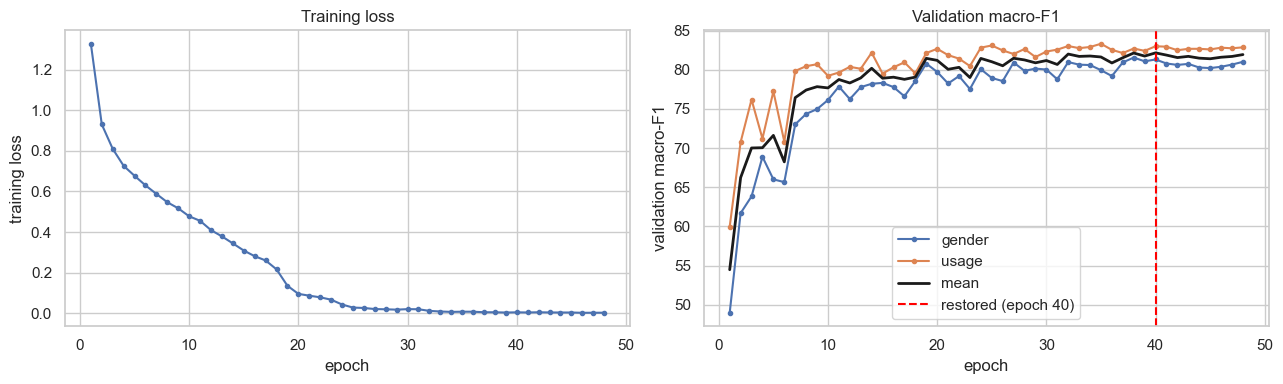

In [61]:
# ============================================
# CELL 11 - Train the model
# ============================================

print("Training the reference configuration: VGG-style blocks, early branching,")
print("ReLU, max pooling, flatten head.\n")

run("base", lambda: EarlyBranchCNN(NUM_CLASSES))

history = HISTORIES["base"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["epoch"], history["train_loss"], marker=".")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss")
axes[0].set_title("Training loss")
axes[1].plot(history["epoch"], history["val_gender_f1"], marker=".", label="gender")
axes[1].plot(history["epoch"], history["val_usage_f1"], marker=".", label="usage")
axes[1].plot(history["epoch"], history["val_mean_f1"], "k-", lw=2, label="mean")
best_epoch = history.loc[history["val_mean_f1"].idxmax(), "epoch"]
axes[1].axvline(best_epoch, ls="--", color="red", label=f"restored (epoch {int(best_epoch)})")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation macro-F1")
axes[1].set_title("Validation macro-F1"); axes[1].legend()
plt.tight_layout(); plt.show()

## Part 5 — Verifying the open design choices

Three choices in Part 2 were argued from principle but are worth confirming on this data:
the activation, the pooling operator, and the classifier head. Each is tested by changing that
single factor and leaving everything else identical.

These runs are shortened (`verify_epochs`) because their purpose is comparison, not producing a
deployable model.

The first two variants exchange one operation for another and leave the parameter count
unchanged, so their results are verdicts. The third also shrinks the network, so its result is
a trade between accuracy and size rather than a verdict, and is read as such.

In [62]:
# ============================================
# CELL 12 - One factor at a time
# ============================================

VERIFY = {"max_epochs": CONFIG["verify_epochs"], "early_stopping_patience": 4}

print("5.1  tanh instead of ReLU")
run("tanh", lambda: EarlyBranchCNN(NUM_CLASSES, activation="tanh"), config=VERIFY)

print("\n5.2  average pooling instead of max")
run("avgpool", lambda: EarlyBranchCNN(NUM_CLASSES, pooling="avg"), config=VERIFY)

print("\n5.3  global average pooling instead of flatten")
run("gap_head", lambda: EarlyBranchCNN(NUM_CLASSES, head="gap"), config=VERIFY)

print("\n5.0  reference, same shortened budget so the comparison is fair")
run("base_short", lambda: EarlyBranchCNN(NUM_CLASSES), config=VERIFY)

5.1  tanh instead of ReLU
  [tanh] epoch  1/15 loss 1.2929 val mean macro-F1 44.39  best
  [tanh] epoch  2/15 loss 1.0009 val mean macro-F1 61.94  best
  [tanh] epoch  3/15 loss 0.8954 val mean macro-F1 62.95  best
  [tanh] epoch  4/15 loss 0.8386 val mean macro-F1 70.09  best
  [tanh] epoch  5/15 loss 0.7954 val mean macro-F1 65.06
  [tanh] epoch  6/15 loss 0.7551 val mean macro-F1 71.78  best
  [tanh] epoch  7/15 loss 0.7246 val mean macro-F1 72.96  best
  [tanh] epoch  8/15 loss 0.6966 val mean macro-F1 74.18  best
  [tanh] epoch 10/15 loss 0.6503 val mean macro-F1 74.10
  [tanh] epoch 12/15 loss 0.6135 val mean macro-F1 75.21  best
  [tanh] epoch 14/15 loss 0.5836 val mean macro-F1 76.03  best
  [tanh] epoch 15/15 loss 0.5539 val mean macro-F1 76.36  best
  [tanh] best 76.36 at epoch 15 (6.9 min)
tanh                   gender 73.37 | usage 79.35 | mean 76.36 | exact 77.33

5.2  average pooling instead of max
  [avgpool] epoch  1/15 loss 1.2365 val mean macro-F1 42.71  best
  [avgpo

EarlyBranchCNN(
  (shared): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (branches): Mod

,change,mean macro-F1,difference,parameters
0,"reference (ReLU, max pool, flatten)",79.85,0.00,4249577
1,tanh instead of ReLU,76.36,-3.49,4249577
2,average pooling instead of max,76.52,-3.33,4249577
3,global average pooling instead of flatten,78.51,-1.34,2414569


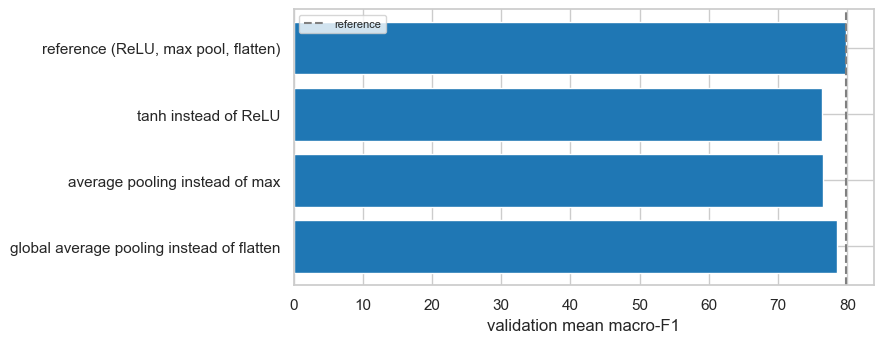

Differences are interpreted against the sampling error computed in Part 7.
A change smaller than that is not attributable to the factor being varied.


In [63]:
# ============================================
# CELL 13 - Design verification results
# ============================================

reference = RESULTS["base_short"]["mean_macro_f1"]
verification = pd.DataFrame([
    {"change": "reference (ReLU, max pool, flatten)", "tag": "base_short"},
    {"change": "tanh instead of ReLU", "tag": "tanh"},
    {"change": "average pooling instead of max", "tag": "avgpool"},
    {"change": "global average pooling instead of flatten", "tag": "gap_head"},
])
verification["mean macro-F1"] = [round(RESULTS[t]["mean_macro_f1"], 2)
                                 for t in verification["tag"]]
verification["difference"] = (verification["mean macro-F1"] - round(reference, 2)).round(2)
verification["parameters"] = [count_parameters(MODELS[t]) for t in verification["tag"]]
display(verification[["change", "mean macro-F1", "difference", "parameters"]])

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(verification["change"], verification["mean macro-F1"], color="tab:blue")
ax.axvline(reference, ls="--", color="grey", label="reference")
ax.set_xlabel("validation mean macro-F1"); ax.legend(fontsize=8)
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print("Differences are interpreted against the sampling error computed in Part 7.")
print("A change smaller than that is not attributable to the factor being varied.")

# Two of the variants swap one operation for another and leave the parameter count
# untouched. The classifier head also changes the size of the network, so its result
# is a trade rather than a verdict, and worth naming explicitly.
variants = verification.iloc[1:]
closest = variants["difference"].abs().idxmin()
reduction = 100 * (1 - verification.loc[closest, "parameters"]
                   / verification.loc[0, "parameters"])
print(f"\nNarrowest margin: {verification.loc[closest, 'change']} "
      f"at {verification.loc[closest, 'difference']:+.2f}.")
if reduction > 1:
    print(f"It is also the only variant that shrinks the network, by {reduction:.0f}% "
          f"of its parameters,\nso a deployment constrained by size could reasonably "
          f"decide this one the other way.")

## Part 6 — Class imbalance

`usage` is 77% `Casual`. In a batch of 128 images drawn at random, roughly 99 are Casual and 7
are Formal, so the network sees the majority class an order of magnitude more often.

The first step is to establish the mechanism by which the imbalance harms performance, because
the symptom is easily misdiagnosed. If the network were labelling everything `Casual`, that class
would be substantially over-predicted and its precision would be low. Cell 14 tests this before
any correction is applied.

Two corrections are then evaluated:

1. **Balanced batch sampling** — construct each batch with equal numbers of each class, drawn
   fresh from the full pool. This has the same effect as duplicating minority rows, without
   repeating fixed copies that the network can memorise.
2. **Balanced sampling with mild augmentation** — adding horizontal flips and small
   scale/translation jitter. Rotation is deliberately excluded: the evaluation images are
   upright catalogue photographs, so training on tilted garments would spend capacity on a
   situation that never occurs.

Both alter how the network is trained rather than how its outputs are interpreted.

Each correction is judged on two quantities: macro-F1, which is the metric the model is selected
on, and the recall of the weakest `usage` class, which is what the correction is intended to
raise. The two need not move together. Because one network predicts both attributes, the
effect of a usage-balanced sampler on the gender head is measured as well.

In [64]:
# ============================================
# CELL 14 - Diagnosing the cost of the imbalance
# ============================================

base_val = predict(MODELS["base"], val_loader)

print(classification_report(base_val["usage"]["true"], base_val["usage"]["pred"],
                            target_names=class_names["usage"], zero_division=0, digits=3))

predicted = Counter(base_val["usage"]["pred"])
actual = Counter(base_val["usage"]["true"])
comparison = pd.DataFrame({
    "class": class_names["usage"],
    "actual": [actual[i] for i in range(NUM_CLASSES["usage"])],
    "predicted": [predicted[i] for i in range(NUM_CLASSES["usage"])],
})
comparison["over-predicted by"] = comparison["predicted"] - comparison["actual"]
display(comparison)

recall = [np.mean(base_val["usage"]["pred"][base_val["usage"]["true"] == i] == i)
          for i in range(NUM_CLASSES["usage"])]
weakest = int(np.argmin(recall))
print(f"weakest class: {class_names['usage'][weakest]}, "
      f"recall {recall[weakest] * 100:.1f}%")
print("Indiscriminate prediction of the majority class would show as a large positive")
print("over-prediction count for Casual together with low precision on that class.")
print("The table above determines whether that is the mechanism at work here.")

              precision    recall  f1-score   support

      Casual      0.928     0.951     0.939      4244
      Ethnic      0.827     0.881     0.853       369
      Formal      0.876     0.791     0.831       330
      Sports      0.769     0.638     0.697       563

    accuracy                          0.904      5506
   macro avg      0.850     0.815     0.830      5506
weighted avg      0.902     0.904     0.902      5506



,class,actual,predicted,over-predicted by
0,Casual,4244,4348,104
1,Ethnic,369,393,24
2,Formal,330,298,-32
3,Sports,563,467,-96


weakest class: Sports, recall 63.8%
Indiscriminate prediction of the majority class would show as a large positive
over-prediction count for Casual together with low precision on that class.
The table above determines whether that is the mechanism at work here.


In [65]:
# ============================================
# CELL 15 - Balanced batch sampling
# ============================================

class BalancedBatchSampler(Sampler):
    """Each batch holds an equal number of every class, sampled with replacement
    from the full pool so minority items are not repeated in fixed combinations."""

    def __init__(self, labels, batch_size=128, batches_per_epoch=None, seed=RANDOM_STATE):
        self.labels = np.asarray(labels)
        self.classes = np.unique(self.labels)
        self.per_class = max(1, batch_size // len(self.classes))
        self.batch_size = self.per_class * len(self.classes)
        self.by_class = {c: np.where(self.labels == c)[0] for c in self.classes}
        self.batches_per_epoch = batches_per_epoch or (len(self.labels) // self.batch_size)
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        for _ in range(self.batches_per_epoch):
            batch = []
            for cls in self.classes:
                pool = self.by_class[cls]
                batch.extend(self.rng.choice(pool, self.per_class,
                                             replace=len(pool) < self.per_class))
            self.rng.shuffle(batch)
            yield [int(i) for i in batch]


sampler = BalancedBatchSampler(train_df["usage_y"].to_numpy(), CONFIG["batch_size"])
print(f"batch composition: {sampler.per_class} per class x "
      f"{len(sampler.classes)} classes = {sampler.batch_size} images")
print(f"batches per epoch: {len(sampler)}")

natural = train_df["usage_y"].value_counts(normalize=True).sort_index()
print("\nusage share per batch, before and after balancing:")
display(pd.DataFrame({
    "class": class_names["usage"],
    "natural %": (natural.values * 100).round(1),
    "balanced %": [round(100 / len(sampler.classes), 1)] * len(sampler.classes)}))

balanced_loader = make_loader(train_df, batch_sampler=sampler)
run("balanced", lambda: EarlyBranchCNN(NUM_CLASSES), loader_train=balanced_loader)

batch composition: 32 per class x 4 classes = 128 images
batches per epoch: 215

usage share per batch, before and after balancing:


,class,natural %,balanced %
0,Casual,77.1,25.0
1,Ethnic,6.7,25.0
2,Formal,6.0,25.0
3,Sports,10.2,25.0


  [balanced] epoch  1/60 loss 1.1367 val mean macro-F1 51.22  best
  [balanced] epoch  2/60 loss 0.7179 val mean macro-F1 55.26  best
  [balanced] epoch  3/60 loss 0.6012 val mean macro-F1 64.06  best
  [balanced] epoch  4/60 loss 0.5232 val mean macro-F1 66.99  best
  [balanced] epoch  5/60 loss 0.4642 val mean macro-F1 67.74  best
  [balanced] epoch  6/60 loss 0.3978 val mean macro-F1 70.92  best
  [balanced] epoch  7/60 loss 0.3693 val mean macro-F1 71.82  best
  [balanced] epoch  8/60 loss 0.3377 val mean macro-F1 72.19  best
  [balanced] epoch  9/60 loss 0.2998 val mean macro-F1 73.84  best
  [balanced] epoch 10/60 loss 0.2776 val mean macro-F1 71.32
  [balanced] epoch 11/60 loss 0.2506 val mean macro-F1 74.04  best
  [balanced] epoch 12/60 loss 0.2316 val mean macro-F1 75.94  best
  [balanced] epoch 14/60 loss 0.2006 val mean macro-F1 76.06  best
  [balanced] epoch 15/60 loss 0.1810 val mean macro-F1 76.30  best
  [balanced] epoch 16/60 loss 0.1736 val mean macro-F1 77.21  best
 

EarlyBranchCNN(
  (shared): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (branches): Mod

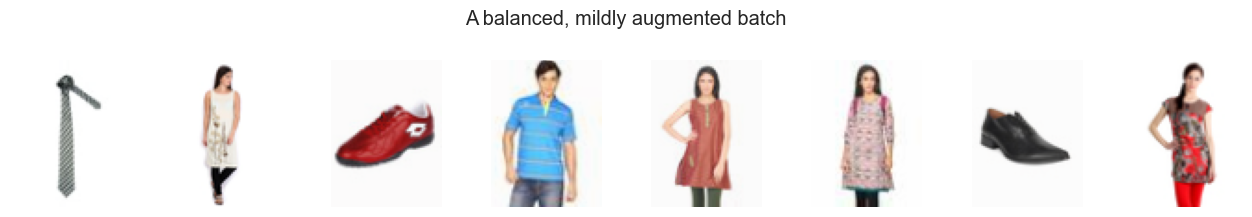

  [balanced_aug] epoch  1/60 loss 1.3309 val mean macro-F1 46.80  best
  [balanced_aug] epoch  2/60 loss 0.9363 val mean macro-F1 47.80  best
  [balanced_aug] epoch  3/60 loss 0.8286 val mean macro-F1 64.52  best
  [balanced_aug] epoch  5/60 loss 0.6962 val mean macro-F1 59.25
  [balanced_aug] epoch  8/60 loss 0.5376 val mean macro-F1 67.52  best
  [balanced_aug] epoch  9/60 loss 0.5043 val mean macro-F1 68.35  best
  [balanced_aug] epoch 10/60 loss 0.4823 val mean macro-F1 70.64  best
  [balanced_aug] epoch 14/60 loss 0.4219 val mean macro-F1 71.62  best
  [balanced_aug] epoch 15/60 loss 0.4061 val mean macro-F1 69.86
  [balanced_aug] epoch 18/60 loss 0.3641 val mean macro-F1 72.97  best
  [balanced_aug] epoch 20/60 loss 0.3413 val mean macro-F1 73.23  best
  [balanced_aug] epoch 21/60 loss 0.3277 val mean macro-F1 74.28  best
  [balanced_aug] epoch 23/60 loss 0.3106 val mean macro-F1 74.37  best
  [balanced_aug] epoch 24/60 loss 0.3088 val mean macro-F1 74.76  best
  [balanced_aug] e

EarlyBranchCNN(
  (shared): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (branches): Mod

In [66]:
# ============================================
# CELL 16 - Balanced sampling with mild augmentation
# ============================================

def gentle_augment(tensor):
    """Horizontal flip, small scale and translation, mild brightness.

    No rotation: the evaluation images are upright, so tilted training examples
    would not resemble anything the model is asked to classify.
    """
    if torch.rand(1).item() < 0.5:
        tensor = torch.flip(tensor, dims=[2])

    scale = 1.0 + (torch.rand(1).item() * 2 - 1) * 0.10
    shift_x = (torch.rand(1).item() * 2 - 1) * 0.05
    shift_y = (torch.rand(1).item() * 2 - 1) * 0.05
    theta = torch.tensor([[1 / scale, 0.0, shift_x],
                          [0.0, 1 / scale, shift_y]], dtype=torch.float32).unsqueeze(0)
    grid = F.affine_grid(theta, (1,) + tuple(tensor.shape), align_corners=False)
    tensor = F.grid_sample(tensor.unsqueeze(0), grid, align_corners=False,
                           padding_mode="border").squeeze(0)

    tensor = tensor * (1.0 + (torch.rand(1).item() * 2 - 1) * 0.10)
    return tensor


augmented_loader = make_loader(
    train_df,
    batch_sampler=BalancedBatchSampler(train_df["usage_y"].to_numpy(),
                                       CONFIG["batch_size"], seed=RANDOM_STATE + 1),
    transform=gentle_augment)

# what the augmentation actually does
sample_images, _, _ = next(iter(augmented_loader))
denorm = (sample_images[:8] * STD_T + MEAN_T).permute(0, 2, 3, 1).numpy()
fig, axes = plt.subplots(1, 8, figsize=(13, 2.2))
for ax, image in zip(axes, denorm):
    ax.imshow(np.clip(image, 0, 1)); ax.axis("off")
plt.suptitle("A balanced, mildly augmented batch")
plt.tight_layout(); plt.show()

# Augmentation presents a slightly different image each epoch, so this configuration
# converges more slowly than the other two. The shared cap in CELL 1 is set wide
# enough for it, and early stopping ends the faster runs sooner.
run("balanced_aug", lambda: EarlyBranchCNN(NUM_CLASSES), loader_train=augmented_loader)

,approach,mean macro-F1,usage macro-F1,weakest usage recall,change vs none
0,no correction,82.16,83.01,63.77,0.00
1,balanced sampling,80.98,84.09,64.12,-1.18
2,balanced + augmentation,78.64,82.46,77.09,-3.52


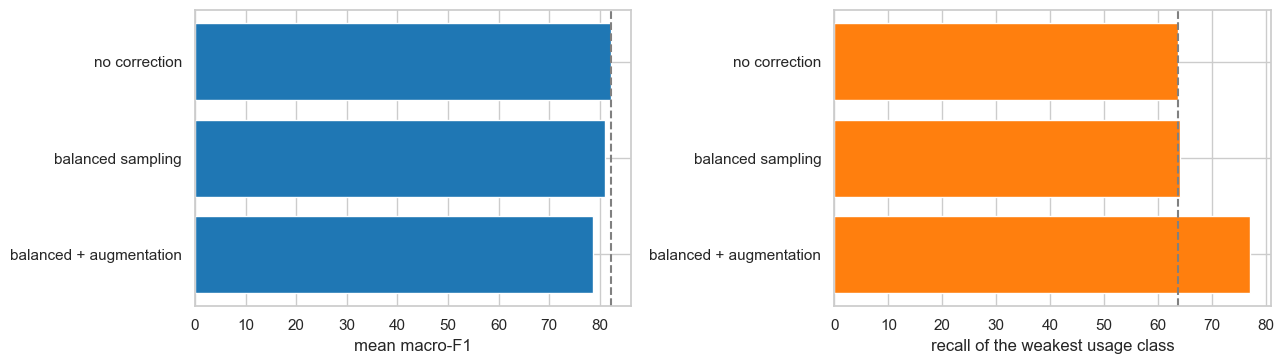

In [67]:
# ============================================
# CELL 17 - Comparison of the two corrections
# ============================================

def weakest_recall(predictions, target="usage"):
    return min(np.mean(predictions[target]["pred"][predictions[target]["true"] == i] == i)
               for i in range(NUM_CLASSES[target])) * 100


rows = [{"approach": "no correction", "mean macro-F1": RESULTS["base"]["mean_macro_f1"],
         "usage macro-F1": RESULTS["base"]["usage"]["macro_f1"],
         "weakest usage recall": weakest_recall(base_val)},
        {"approach": "balanced sampling", "mean macro-F1": RESULTS["balanced"]["mean_macro_f1"],
         "usage macro-F1": RESULTS["balanced"]["usage"]["macro_f1"],
         "weakest usage recall": weakest_recall(predict(MODELS["balanced"], val_loader))},
        {"approach": "balanced + augmentation",
         "mean macro-F1": RESULTS["balanced_aug"]["mean_macro_f1"],
         "usage macro-F1": RESULTS["balanced_aug"]["usage"]["macro_f1"],
         "weakest usage recall": weakest_recall(predict(MODELS["balanced_aug"], val_loader))}]

imbalance = pd.DataFrame(rows).round(2)
imbalance["change vs none"] = (imbalance["mean macro-F1"]
                               - imbalance["mean macro-F1"].iloc[0]).round(2)
display(imbalance)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].barh(imbalance["approach"], imbalance["mean macro-F1"], color="tab:blue")
axes[0].axvline(imbalance["mean macro-F1"].iloc[0], ls="--", color="grey")
axes[0].set_xlabel("mean macro-F1"); axes[0].invert_yaxis()
axes[1].barh(imbalance["approach"], imbalance["weakest usage recall"], color="tab:orange")
axes[1].axvline(imbalance["weakest usage recall"].iloc[0], ls="--", color="grey")
axes[1].set_xlabel("recall of the weakest usage class"); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

imbalance.to_csv(ARTIFACT_DIR / "imbalance_comparison.csv", index=False)

,approach,gender macro-F1,usage macro-F1,gender change,usage change
0,no correction,81.32,83.01,0.00,0.00
1,balanced sampling,77.88,84.09,-3.44,1.08
2,balanced + augmentation,74.83,82.46,-6.49,-0.55


Gender composition of each usage class in the training split (%):


gender_label,Boys,Girls,Men,Unisex,Women
usage_label,,,,,
Casual,2.6,2.1,52.9,6.0,36.3
Ethnic,0.4,0.3,3.5,0.0,95.9
Formal,0.0,0.0,94.8,0.1,5.1
Sports,0.5,0.1,73.0,7.2,19.2


,natural %,balanced batches %,ratio
gender_label,,,
Boys,2.1,0.9,0.43
Girls,1.7,0.6,0.35
Men,54.2,56.1,1.04
Unisex,5.4,3.3,0.61
Women,36.7,39.1,1.07


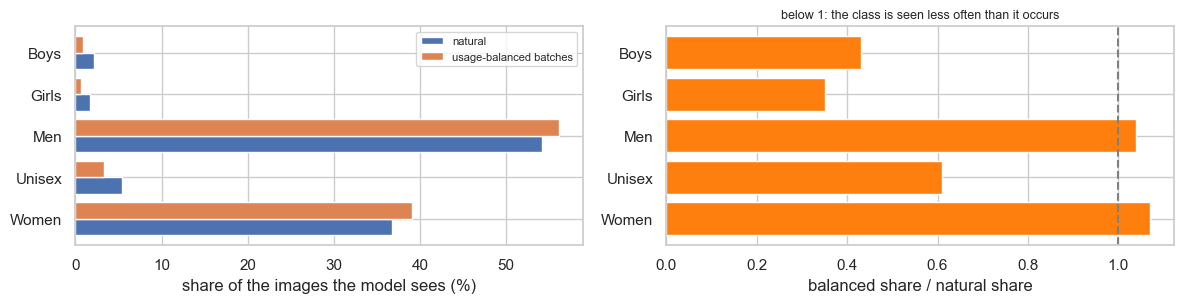

Balanced sampling changed usage macro-F1 by +1.08 and gender macro-F1 by -3.44.

The minority usage classes are dominated by the majority genders (Ethnic is 96% Women, Formal is 95% Men),
so drawing them equally makes the rare gender classes rarer still: Girls falls from 1.7%
to 0.6% of the images the model sees, a factor of 0.35.
Gender macro-F1 weights all five classes equally, which is where the cost appears.

These are single runs; both configurations are repeated across seeds in Part 7.


In [68]:
# ============================================
# CELL 18 - The effect of the sampler on the other attribute
# ============================================

# The sampler equalises the four usage classes. Gender and usage are not
# independent, so changing one distribution changes the other. This cell measures
# what the gender head is trained on once the sampler is in place.

attribute_cost = pd.DataFrame([
    {"approach": label,
     "gender macro-F1": round(RESULTS[tag]["gender"]["macro_f1"], 2),
     "usage macro-F1": round(RESULTS[tag]["usage"]["macro_f1"], 2)}
    for label, tag in [("no correction", "base"),
                       ("balanced sampling", "balanced"),
                       ("balanced + augmentation", "balanced_aug")]])
for column in ["gender macro-F1", "usage macro-F1"]:
    attribute_cost[column.replace("macro-F1", "change")] = (
        attribute_cost[column] - attribute_cost[column].iloc[0]).round(2)
display(attribute_cost)

# The composition of each usage class is what the sampler re-weights.
mix = pd.crosstab(train_df["usage_label"], train_df["gender_label"],
                  normalize="index") * 100
print("Gender composition of each usage class in the training split (%):")
display(mix.round(1))

# With equal numbers of every usage class in each batch, the gender distribution
# the model sees becomes the unweighted mean of the rows above, not the true one.
natural = train_df["gender_label"].value_counts(normalize=True).sort_index() * 100
exposure = pd.DataFrame({"natural %": natural.round(1),
                         "balanced batches %": mix.mean(axis=0).round(1)})
exposure["ratio"] = (exposure["balanced batches %"] / exposure["natural %"]).round(2)
display(exposure)

offset = np.arange(len(exposure))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
axes[0].barh(offset + 0.2, exposure["natural %"], height=0.4, label="natural")
axes[0].barh(offset - 0.2, exposure["balanced batches %"], height=0.4,
             label="usage-balanced batches")
axes[0].set_xlabel("share of the images the model sees (%)")
axes[0].legend(fontsize=8)

axes[1].barh(offset, exposure["ratio"], color="tab:orange")
axes[1].axvline(1.0, ls="--", color="grey")
axes[1].set_xlabel("balanced share / natural share")
axes[1].set_title("below 1: the class is seen less often than it occurs", fontsize=9)

for ax in axes:
    ax.set_yticks(offset); ax.set_yticklabels(exposure.index); ax.invert_yaxis()
plt.tight_layout(); plt.show()

dominant = mix.idxmax(axis=1)
skewed = ", ".join(f"{usage} is {mix.loc[usage, dominant[usage]]:.0f}% {dominant[usage]}"
                   for usage in mix.index if mix.loc[usage, dominant[usage]] > 80)
starved = exposure["ratio"].idxmin()

print(f"Balanced sampling changed usage macro-F1 by "
      f"{attribute_cost.loc[1, 'usage change']:+.2f} and gender macro-F1 by "
      f"{attribute_cost.loc[1, 'gender change']:+.2f}.")
print(f"\nThe minority usage classes are dominated by the majority genders ({skewed}),")
print(f"so drawing them equally makes the rare gender classes rarer still: {starved} falls "
      f"from {exposure.loc[starved, 'natural %']:.1f}%")
print(f"to {exposure.loc[starved, 'balanced batches %']:.1f}% of the images the model sees, "
      f"a factor of {exposure.loc[starved, 'ratio']:.2f}.")
print("Gender macro-F1 weights all five classes equally, which is where the cost appears.")
print("\nThese are single runs; both configurations are repeated across seeds in Part 7.")

exposure.to_csv(ARTIFACT_DIR / "sampler_gender_exposure.csv")


## Part 7 — Model selection and test results

Selection is performed on the validation partition alone. The test partition is held out until
the model is fixed, and is evaluated exactly once.

Two quantities bound how precisely two configurations can be compared. The first is the sampling
error of the validation set, which reflects its finite size. The second is the variation between
independent training runs of the same configuration, which arises from the random initialisation,
the ordering of batches, and non-deterministic GPU kernels. A difference smaller than either
quantity is not evidence of a difference in the configurations.

Every criterion in the selection rule is judged against that same threshold, including the
tie-break: a difference too small to separate two configurations on the primary metric cannot
decide between them on a secondary one either. Where nothing separates the candidates, the
configuration requiring the least machinery is retained.

### Run-to-run variability

A configuration's score moves between runs of identical code: the weights are initialised
randomly, the batch ordering differs, and several GPU kernels are non-deterministic. One run
therefore cannot establish that one configuration is better than another. Each remaining
configuration is trained under three random seeds, and the standard deviation across those runs
is taken as an estimate of the training variance.

The larger of the two uncertainties — sampling error and training variance — is used as the
threshold below which two configurations are treated as indistinguishable.

In [69]:
# ============================================
# CELL 19 - Repeated training runs across random seeds
# ============================================

SEEDS = [RANDOM_STATE, 7, 2024]        # the first seed reuses the runs already trained above


def build_base():
    return EarlyBranchCNN(NUM_CLASSES)


def loader_for(name, seed):
    """The training loader a configuration needs; None means the default loader."""
    if name == "balanced":
        return make_loader(train_df, batch_sampler=BalancedBatchSampler(
            train_df["usage_y"].to_numpy(), CONFIG["batch_size"], seed=seed))
    if name == "balanced_aug":
        return make_loader(train_df, batch_sampler=BalancedBatchSampler(
            train_df["usage_y"].to_numpy(), CONFIG["batch_size"], seed=seed + 1),
            transform=gentle_augment)
    return None


repeat_rows, seed_models = [], {}

for name in ["base", "balanced", "balanced_aug"]:
    for seed in SEEDS:
        tag = f"{name}-s{seed}"
        if seed == SEEDS[0] and name in RESULTS:       # already trained in Part 6
            summary, model = RESULTS[name], MODELS[name]
        else:
            set_seed(seed)
            model, _ = train_model(build_base(), tag,
                                   loader_train=loader_for(name, seed), verbose=False)
            summary = summarise(predict(model, val_loader))
        seed_models[(name, seed)] = model
        repeat_rows.append({
            "configuration": name, "seed": seed,
            "mean macro-F1": round(summary["mean_macro_f1"], 2),
            "usage macro-F1": round(summary["usage"]["macro_f1"], 2),
            "gender macro-F1": round(summary["gender"]["macro_f1"], 2),
            "exact match": round(summary["exact_match"], 2)})
        print(f"  {name:9s} seed {seed:>4} -> mean {repeat_rows[-1]['mean macro-F1']:6.2f} | "
              f"usage {repeat_rows[-1]['usage macro-F1']:6.2f} | "
              f"gender {repeat_rows[-1]['gender macro-F1']:6.2f}")

repeats = pd.DataFrame(repeat_rows)
display(repeats)

  base      seed   42 -> mean  82.16 | usage  83.01 | gender  81.32
  base      seed    7 -> mean  81.21 | usage  83.31 | gender  79.10
  base      seed 2024 -> mean  79.84 | usage  82.08 | gender  77.60
  balanced  seed   42 -> mean  80.98 | usage  84.09 | gender  77.88
  balanced  seed    7 -> mean  80.22 | usage  83.05 | gender  77.38
  balanced  seed 2024 -> mean  81.23 | usage  82.91 | gender  79.55
  balanced_aug seed   42 -> mean  78.64 | usage  82.46 | gender  74.83
  balanced_aug seed    7 -> mean  80.80 | usage  82.77 | gender  78.83
  balanced_aug seed 2024 -> mean  79.42 | usage  81.63 | gender  77.21


,configuration,seed,mean macro-F1,usage macro-F1,gender macro-F1,exact match
0,base,42,82.16,83.01,81.32,82.27
1,base,7,81.21,83.31,79.10,81.84
2,base,2024,79.84,82.08,77.60,80.33
3,balanced,42,80.98,84.09,77.88,81.53
4,balanced,7,80.22,83.05,77.38,80.64
5,balanced,2024,81.23,82.91,79.55,80.68
6,balanced_aug,42,78.64,82.46,74.83,78.61
7,balanced_aug,7,80.80,82.77,78.83,80.06
8,balanced_aug,2024,79.42,81.63,77.21,78.01


,runs,mean,sd,usage_mean,usage_sd,exact_mean
configuration,,,,,,
balanced,3,80.81,0.53,83.35,0.64,80.95
balanced_aug,3,79.62,1.09,82.29,0.59,78.89
base,3,81.07,1.17,82.80,0.64,81.48


sampling error of the validation set    : +-0.67
largest standard deviation across seeds : +-1.17
threshold for a meaningful difference   : +-1.17



,mean macro-F1,vs leader,usage macro-F1,usage vs leader,within threshold
configuration,,,,,
base,81.07,0.00,82.80,0.00,True
balanced,80.81,-0.26,83.35,0.55,True
balanced_aug,79.62,-1.45,82.29,-0.51,False


leading configuration: base

  balanced       indistinguishable from the leader on the mean (-0.26);
                 usage macro-F1 +0.55 against the leader
  balanced_aug   below the leader by more than the threshold (-1.45);
                 usage macro-F1 -0.51 against the leader

Within the threshold of the leader: ['base', 'balanced'].
Selection in the next cell ranks on this table and breaks remaining ties on
usage macro-F1, the attribute the corrections in Part 6 were intended to improve.


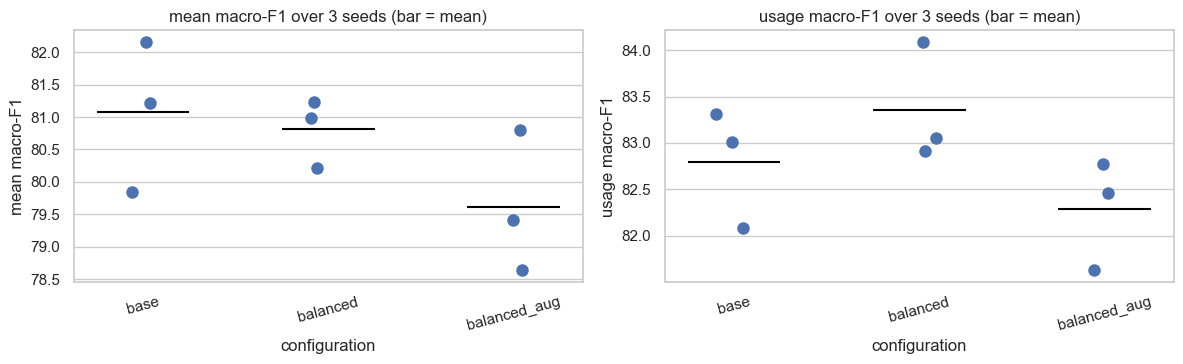

In [70]:
# ============================================
# CELL 20 - Decomposing the uncertainty
# ============================================

stats = repeats.groupby("configuration").agg(
    runs=("mean macro-F1", "size"),
    mean=("mean macro-F1", "mean"), sd=("mean macro-F1", "std"),
    usage_mean=("usage macro-F1", "mean"), usage_sd=("usage macro-F1", "std"),
    exact_mean=("exact match", "mean")).round(2)
display(stats)

# Sampling error of a proportion estimated on the validation set: the uncertainty
# attributable to its finite size alone.
NOISE_FLOOR = 100 * np.sqrt(0.5 * 0.5 / len(val_df))
spread = float(repeats.groupby("configuration")["mean macro-F1"].std().max())
EFFECTIVE_NOISE = max(NOISE_FLOOR, spread)

print(f"sampling error of the validation set    : +-{NOISE_FLOOR:.2f}")
print(f"largest standard deviation across seeds : +-{spread:.2f}")
print(f"threshold for a meaningful difference   : +-{EFFECTIVE_NOISE:.2f}\n")

leader = stats["mean"].idxmax()
gaps = pd.DataFrame({
    "mean macro-F1": stats["mean"],
    "vs leader": (stats["mean"] - stats.loc[leader, "mean"]).round(2),
    "usage macro-F1": stats["usage_mean"],
    "usage vs leader": (stats["usage_mean"] - stats.loc[leader, "usage_mean"]).round(2),
}).sort_values("mean macro-F1", ascending=False)
gaps["within threshold"] = (stats.loc[leader, "mean"] - gaps["mean macro-F1"]) < EFFECTIVE_NOISE
display(gaps)

print(f"leading configuration: {leader}\n")
for name in gaps.index:
    if name == leader:
        continue
    difference, usage_difference = gaps.loc[name, ["vs leader", "usage vs leader"]]
    if abs(difference) < EFFECTIVE_NOISE:
        verdict = "indistinguishable from the leader on the mean"
    else:
        verdict = "below the leader by more than the threshold"
    print(f"  {name:14s} {verdict} ({difference:+.2f});")
    print(f"  {'':14s} usage macro-F1 {usage_difference:+.2f} against the leader")

tied = list(gaps.index[gaps["within threshold"]])
print(f"\nWithin the threshold of the leader: {tied}.")
print("Selection in the next cell ranks on this table and breaks remaining ties on")
print("usage macro-F1, the attribute the corrections in Part 6 were intended to improve.")

# The order is stated explicitly so that each mean bar lands on its own column:
# seaborn orders categories by first appearance, which is not the order of `stats`.
ORDER = list(gaps.index)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, column, key in [(axes[0], "mean macro-F1", "mean"),
                        (axes[1], "usage macro-F1", "usage_mean")]:
    sns.stripplot(data=repeats, x="configuration", y=column, ax=ax, size=9, order=ORDER)
    for position, name in enumerate(ORDER):
        ax.hlines(stats.loc[name, key], position - 0.25, position + 0.25, color="black")
    ax.set_title(f"{column} over {len(SEEDS)} seeds (bar = mean)")
    ax.tick_params(axis="x", labelrotation=15)
plt.tight_layout(); plt.show()

repeats.to_csv(ARTIFACT_DIR / "seed_repeats.csv", index=False)


In [77]:
# ============================================
# CELL 21 - Selection
# ============================================

# Selection rule, fixed before the scores are examined and applied in order:
#   1. rank on mean macro-F1, averaged over the three seeds;
#   2. treat every configuration within EFFECTIVE_NOISE of the leader as tied;
#   3. among tied configurations, prefer the one with the higher usage macro-F1,
#      since usage is the attribute the corrections in Part 6 were intended to
#      improve, but only where that advantage itself exceeds EFFECTIVE_NOISE;
#   4. otherwise prefer the simpler pipeline, and then the smaller model.
# All three configurations are trained under the same epoch cap and the same three
# seeds, so the ranking compares like with like.
#
# Step 3 originally carried no threshold of its own. Applied that way it selected a
# configuration whose usage advantage was smaller than EFFECTIVE_NOISE, which is a
# margin this notebook treats as indistinguishable everywhere else. A criterion
# cannot decide on a difference it has already classified as noise, so the same
# threshold now governs both steps, and step 4 falls through to the configuration
# that requires the least machinery: the standard loader ahead of a custom sampler,
# and a custom sampler ahead of one combined with augmentation.

print(f"validation set: {len(val_df):,} images")
print(f"sampling error       +-{NOISE_FLOOR:.2f}   "
      f"training variance +-{spread:.2f}   "
      f"threshold +-{EFFECTIVE_NOISE:.2f}\n")

averaged = repeats.groupby("configuration")[["mean macro-F1", "usage macro-F1",
                                             "exact match"]].mean()


def score(tag, column, fallback):
    """Seed-averaged score where repeats exist, otherwise the single run."""
    if tag in averaged.index:
        return round(float(averaged.loc[tag, column]), 2)
    return round(fallback, 2)


candidates = ["base", "balanced", "balanced_aug"]
selection = pd.DataFrame([
    {"model": tag,
     "runs": int((repeats["configuration"] == tag).sum()) or 1,
     "mean macro-F1": score(tag, "mean macro-F1", RESULTS[tag]["mean_macro_f1"]),
     "usage macro-F1": score(tag, "usage macro-F1", RESULTS[tag]["usage"]["macro_f1"]),
     "exact match": score(tag, "exact match", RESULTS[tag]["exact_match"]),
     "parameters": count_parameters(MODELS[tag])}
    for tag in candidates]).sort_values("mean macro-F1", ascending=False)
display(selection)

# Steps 1 and 2.
leader = selection.iloc[0]["model"]
best_score = selection.iloc[0]["mean macro-F1"]
tied = selection[selection["mean macro-F1"] >= best_score - EFFECTIVE_NOISE]

# Step 3, applied only where the tie-break margin clears the same threshold.
leader_usage = float(selection.loc[selection["model"] == leader,
                                   "usage macro-F1"].iloc[0])
decisive = tied[tied["usage macro-F1"] - leader_usage > EFFECTIVE_NOISE]

# Step 4: least machinery first, then fewest parameters.
COMPLEXITY = {"base": 0, "balanced": 1, "balanced_aug": 2}

if len(decisive):
    FINAL_NAME = decisive.sort_values("usage macro-F1",
                                      ascending=False).iloc[0]["model"]
    SELECTION_REASON = "usage macro-F1 is ahead by more than the threshold"
else:
    FINAL_NAME = (tied.assign(complexity=tied["model"].map(COMPLEXITY))
                  .sort_values(["complexity", "parameters"]).iloc[0]["model"])
    SELECTION_REASON = ("no criterion separates the tied configurations by more "
                        "than the threshold,\nso the simplest pipeline is retained")

# Among the seeds trained for the selected configuration, retain the strongest.
seed_scores = repeats[repeats["configuration"] == FINAL_NAME]
if len(seed_scores):
    BEST_SEED = int(seed_scores.sort_values("mean macro-F1",
                                            ascending=False).iloc[0]["seed"])
    FINAL_MODEL = seed_models[(FINAL_NAME, BEST_SEED)]
else:
    BEST_SEED = RANDOM_STATE
    FINAL_MODEL = MODELS[FINAL_NAME]

print(f"within +-{EFFECTIVE_NOISE:.2f} of the leader: {list(tied['model'])}")
if len(tied) > 1:
    print(SELECTION_REASON)
else:
    print("no tie: the leading configuration is ahead by more than the threshold")

print(f"\nselected: {FINAL_NAME}, seed {BEST_SEED}, "
      f"{count_parameters(FINAL_MODEL):,} parameters")

# The corrections in Part 6 were not carried forward. They are retained in the
# notebook because the diagnosis and the negative result are part of the finding:
# balanced sampling raised recall on the weakest usage class but did not improve
# macro-F1 on either attribute, so it purchased coverage of the minority classes
# at the cost of overall performance.
if FINAL_NAME == "base":
    print("\nNeither imbalance correction was retained; see Cell 17 for the trade-off "
          "each produced.")

validation set: 5,506 images
sampling error       +-0.67   training variance +-1.17   threshold +-1.17



,model,runs,mean macro-F1,usage macro-F1,exact match,parameters
0,base,3,81.07,82.80,81.48,4249577
1,balanced,3,80.81,83.35,80.95,4249577
2,balanced_aug,3,79.62,82.29,78.89,4249577


within +-1.17 of the leader: ['base', 'balanced']
no criterion separates the tied configurations by more than the threshold,
so the simplest pipeline is retained

selected: base, seed 42, 4,249,577 parameters

Neither imbalance correction was retained; see Cell 17 for the trade-off each produced.


,target,accuracy,macro-F1,balanced accuracy,majority baseline,gain
0,gender,90.08,77.08,76.39,54.20,35.88
1,usage,91.17,84.28,82.43,77.11,14.07


exact match (both attributes correct): 82.09%

GENDER
              precision    recall  f1-score   support

        Boys      0.744     0.776     0.759       116
       Girls      0.656     0.641     0.648        92
         Men      0.921     0.943     0.932      2984
      Unisex      0.659     0.551     0.600       294
       Women      0.920     0.908     0.914      2020

    accuracy                          0.901      5506
   macro avg      0.780     0.764     0.771      5506
weighted avg      0.899     0.901     0.899      5506


USAGE
              precision    recall  f1-score   support

      Casual      0.932     0.956     0.944      4246
      Ethnic      0.901     0.864     0.882       367
      Formal      0.836     0.806     0.821       330
      Sports      0.787     0.671     0.725       563

    accuracy                          0.912      5506
   macro avg      0.864     0.824     0.843      5506
weighted avg      0.909     0.912     0.910      5506



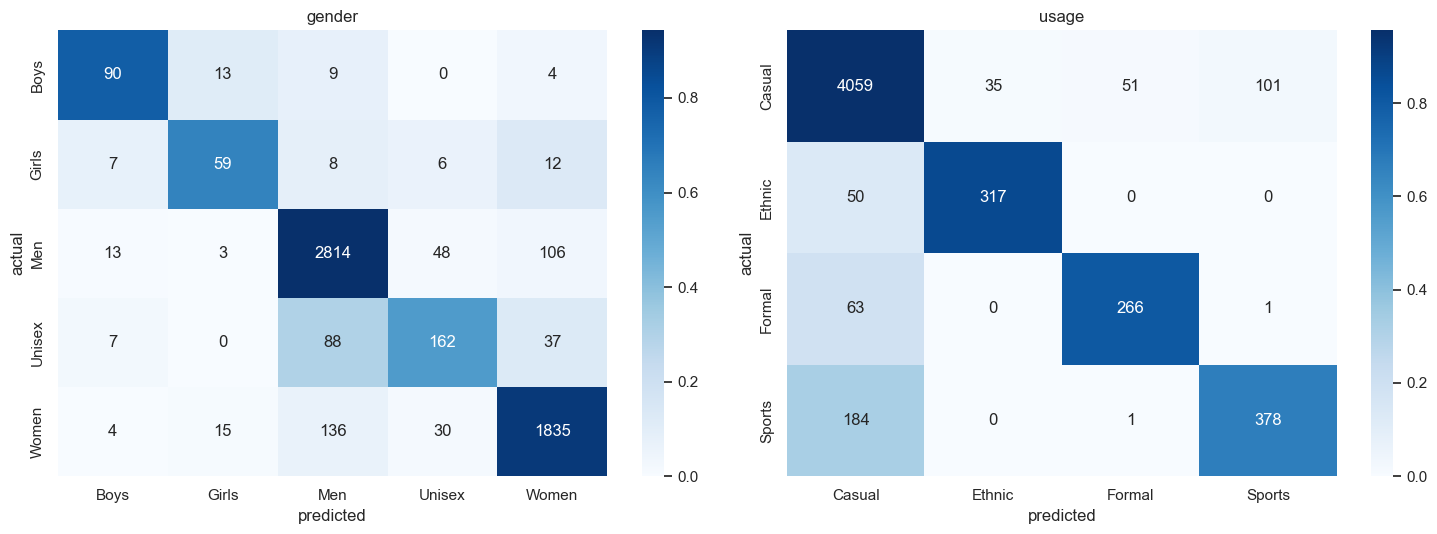

In [78]:
# ============================================
# CELL 22 - Test results
# ============================================

test_predictions = predict(FINAL_MODEL, test_loader)
test_summary = summarise(test_predictions)

final = pd.DataFrame([
    {"target": target,
     "accuracy": round(test_summary[target]["accuracy"], 2),
     "macro-F1": round(test_summary[target]["macro_f1"], 2),
     "balanced accuracy": round(test_summary[target]["balanced_acc"], 2),
     "majority baseline": round(BASELINE[target]["accuracy"], 2),
     "gain": round(test_summary[target]["accuracy"] - BASELINE[target]["accuracy"], 2)}
    for target in CONFIG["targets"]])
display(final)
print(f"exact match (both attributes correct): {test_summary['exact_match']:.2f}%")

for target in CONFIG["targets"]:
    print("\n" + "=" * 58); print(target.upper()); print("=" * 58)
    print(classification_report(test_predictions[target]["true"],
                                test_predictions[target]["pred"],
                                target_names=class_names[target],
                                zero_division=0, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, target in zip(axes, CONFIG["targets"]):
    matrix = confusion_matrix(test_predictions[target]["true"],
                              test_predictions[target]["pred"])
    normalised = matrix / matrix.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(normalised, annot=matrix, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_names[target], yticklabels=class_names[target])
    ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title(target)
plt.tight_layout(); plt.show()

,items,gender %,usage %
masterCategory,,,
Sporting Goods,3,66.7,33.3
Personal Care,158,77.8,100.0
Accessories,1412,80.9,93.8
Footwear,1193,90.4,89.9
Apparel,2733,95.4,89.9
Free Items,7,100.0,85.7


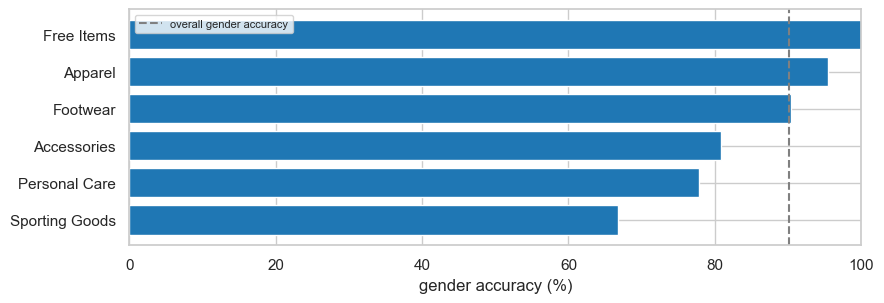

,items,gender %,train examples
group,,,
cosmetics,9,100.0,60
fragrance and other,149,76.5,600


Predicted gender for fragrance, deodorant and gift sets:


gender_pred,Girls,Men,Unisex,Women
gender_label,,,,
Men,1,71,1,17
Unisex,0,0,1,0
Women,0,16,0,42


,share of gender errors %
masterCategory,
Accessories,49.5
Apparel,22.9
Footwear,21.1
Personal Care,6.4
Sporting Goods,0.2


Gender accuracy ranges from 77.8% on Personal Care to 95.4% on Apparel.
The largest single source of error is Accessories, at 49.5% of all gender errors
from 1,412 test items. Personal Care has the lowest rate but contributes
only 6.4%, being 158 items of 5,506.

Accuracy tracks how much of the gender signal is carried by shape. A garment's cut differs
between the men's and women's ranges; a bottle, a watch or a bag frequently does not, and at
60x80 the branding that would separate them is not resolvable.


In [79]:
# ============================================
# CELL 23 - Where the errors are
# ============================================

# Aggregate accuracy hides which kinds of item the model fails on. Every test
# prediction is joined back to its catalogue category, so the failures can be
# attributed rather than only counted.

analysis = test_df.copy()
for target in CONFIG["targets"]:
    analysis[target + "_pred"] = [class_names[target][i]
                                  for i in test_predictions[target]["pred"]]

gender_hit = analysis["gender_label"] == analysis["gender_pred"]
usage_hit = analysis["usage_label"] == analysis["usage_pred"]

by_category = pd.DataFrame({
    "items": analysis.groupby("masterCategory").size(),
    "gender %": (gender_hit.groupby(analysis["masterCategory"]).mean() * 100).round(1),
    "usage %": (usage_hit.groupby(analysis["masterCategory"]).mean() * 100).round(1),
}).sort_values("gender %")
display(by_category)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(by_category.index, by_category["gender %"], color="tab:blue")
ax.axvline(test_summary["gender"]["accuracy"], ls="--", color="grey",
           label="overall gender accuracy")
ax.set_xlabel("gender accuracy (%)"); ax.set_xlim(0, 100); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Personal Care contains two visually distinct populations that carry opposite
# gender priors, so it is split rather than reported as one figure.
COSMETICS = {"Lips", "Nails", "Eyes", "Makeup"}
care = analysis[analysis["masterCategory"] == "Personal Care"].copy()
care["group"] = np.where(care["subCategory"].isin(COSMETICS),
                         "cosmetics", "fragrance and other")
care_hit = care["gender_label"] == care["gender_pred"]
display(pd.DataFrame({
    "items": care.groupby("group").size(),
    "gender %": (care_hit.groupby(care["group"]).mean() * 100).round(1),
    "train examples": [int((train_df["subCategory"].isin(COSMETICS)).sum()),
                       int(((train_df["masterCategory"] == "Personal Care") &
                            (~train_df["subCategory"].isin(COSMETICS))).sum())]}))

fragrance = care[care["group"] == "fragrance and other"]
print("Predicted gender for fragrance, deodorant and gift sets:")
display(pd.crosstab(fragrance["gender_label"], fragrance["gender_pred"]))

# Where the gender errors actually are, as a share of all of them.
error_share = (analysis.loc[~gender_hit, "masterCategory"]
               .value_counts(normalize=True) * 100).round(1)
error_share.name = "share of gender errors %"
display(error_share.to_frame())

substantial = by_category[by_category["items"] >= 50]
worst, best = substantial.index[0], substantial.index[-1]
largest = error_share.index[0]
print(f"Gender accuracy ranges from {substantial.loc[worst, 'gender %']:.1f}% on {worst} "
      f"to {substantial.loc[best, 'gender %']:.1f}% on {best}.")
print(f"The largest single source of error is {largest}, at {error_share.iloc[0]:.1f}% of all "
      f"gender errors\nfrom {int(by_category.loc[largest, 'items']):,} test items. "
      f"{worst} has the lowest rate but contributes\nonly {error_share.get(worst, 0.0):.1f}%, "
      f"being {int(by_category.loc[worst, 'items'])} items of {len(analysis):,}.")
print("\nAccuracy tracks how much of the gender signal is carried by shape. A garment's cut "
      "differs\nbetween the men's and women's ranges; a bottle, a watch or a bag frequently does "
      "not, and at\n60x80 the branding that would separate them is not resolvable.")

by_category.to_csv(ARTIFACT_DIR / "error_analysis.csv")


In [80]:
# ============================================
# CELL 24 - Final architecture specification
# ============================================

settings = FINAL_MODEL.settings
shared_shape = flat_features(FINAL_MODEL.shared)[1]
branch_size, branch_shape = flat_features(
    nn.Sequential(FINAL_MODEL.shared, FINAL_MODEL.branches["gender"]))

specification = pd.DataFrame([
    ("Input", f"{CONFIG['channels']} x {CONFIG['image_height']} x {CONFIG['image_width']} RGB"),
    ("Reference design", "VGG-style: paired 3x3 convolutions per block, channels doubling"),
    ("Multi-task structure", "early branching - shared trunk, then one pathway per attribute"),
    ("Convolution kernel", "3 x 3, stride 1, padding 1 (all layers)"),
    ("Filters, shared trunk", " -> ".join(str(w) for w in settings["shared_widths"])),
    ("Filters, each branch", " -> ".join(str(w) for w in settings["branch_widths"])),
    ("Convolutions per block", "2, each followed by batch normalisation"),
    ("Activation", {"relu": "ReLU", "tanh": "tanh", "sigmoid": "sigmoid"}[settings["activation"]]),
    ("Normalisation", "BatchNorm2d after every convolution"),
    ("Pooling", f"{'max' if settings['pooling'] == 'max' else 'average'} pooling, 2 x 2, stride 2"),
    ("Shared trunk output", f"{shared_shape[0]} x {shared_shape[1]} x {shared_shape[2]}"),
    ("Branch output", f"{branch_shape[0]} x {branch_shape[1]} x {branch_shape[2]}"),
    ("Classifier input", "flatten" if settings["head"] == "flatten"
     else "global average pooling"),
    ("Flattened size", f"{branch_size}" if settings["head"] == "flatten"
     else f"{branch_shape[0]} (one value per channel)"),
    ("Classifier", f"Dropout({settings['dropout']}) -> Linear(., {settings['hidden']}) "
     f"-> ReLU -> Dropout({settings['dropout']}) -> Linear({settings['hidden']}, classes)"),
    ("Output", f"gender {NUM_CLASSES['gender']} scores, usage {NUM_CLASSES['usage']} scores; "
     "softmax applied at prediction time"),
    ("Loss", "cross-entropy per attribute, summed with equal weight"),
    ("Optimiser", f"AdamW, lr {CONFIG['learning_rate']}, weight decay {CONFIG['weight_decay']}"),
    ("Learning rate schedule", "halved after 3 epochs without validation improvement"),
    ("Regularisation", f"dropout {settings['dropout']}, weight decay, batch norm, early stopping"),
    ("Class imbalance", {"base": "none applied",
                         "balanced": "balanced batch sampling (equal classes per batch)",
                         "balanced_aug": "balanced sampling with flip, scale and "
                                         "translation jitter"}.get(FINAL_NAME, FINAL_NAME)),
    ("Training seed", f"{BEST_SEED} (best of {len(SEEDS)} repeated runs)"),
    ("Selection rule", f"highest mean macro-F1 averaged over seeds; ties within "
     f"+-{EFFECTIVE_NOISE:.2f} broken on usage macro-F1"),
    ("Total parameters", f"{count_parameters(FINAL_MODEL):,}"),
], columns=["component", "setting"])

pd.set_option("display.max_colwidth", 90)
display(specification)
specification.to_csv(ARTIFACT_DIR / "final_architecture.csv", index=False)

,component,setting
0,Input,3 x 80 x 60 RGB
1,Reference design,"VGG-style: paired 3x3 convolutions per block, channels doubling"
2,Multi-task structure,"early branching - shared trunk, then one pathway per attribute"
3,Convolution kernel,"3 x 3, stride 1, padding 1 (all layers)"
4,"Filters, shared trunk",32 -> 64
5,"Filters, each branch",128 -> 256
6,Convolutions per block,"2, each followed by batch normalisation"
7,Activation,ReLU
8,Normalisation,BatchNorm2d after every convolution
9,Pooling,"max pooling, 2 x 2, stride 2"


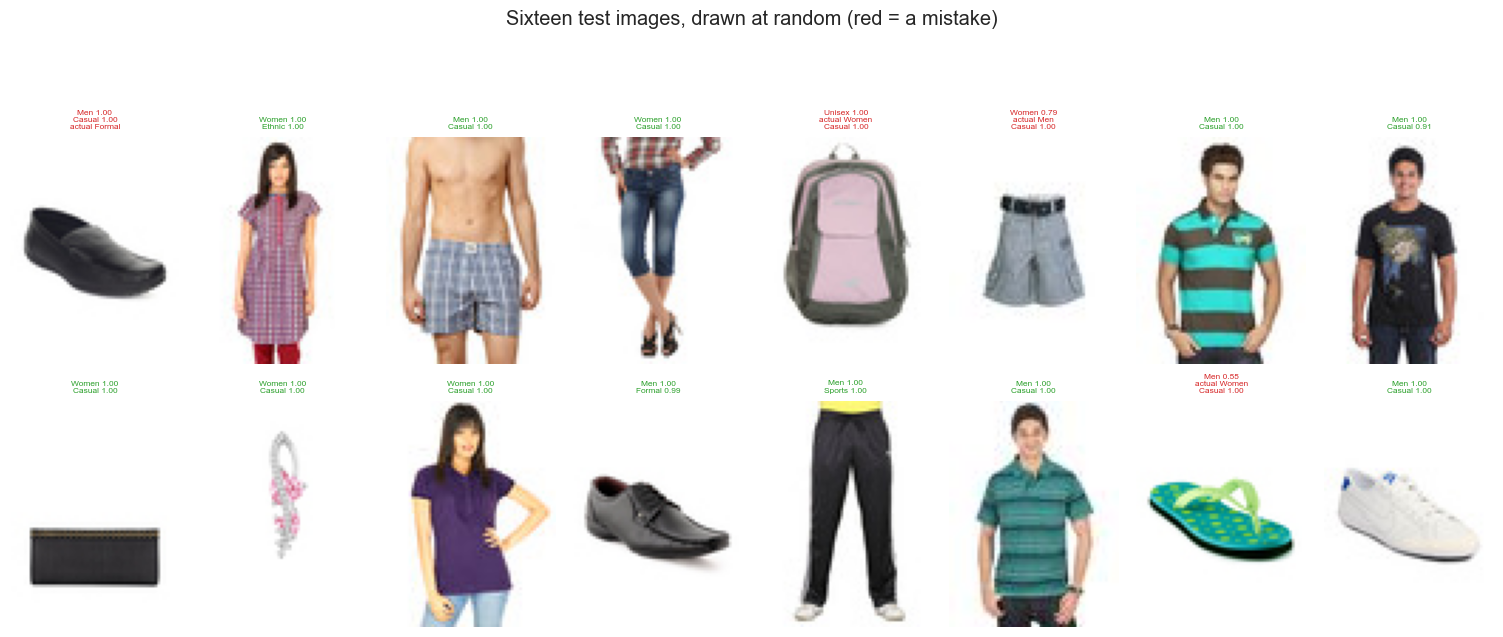

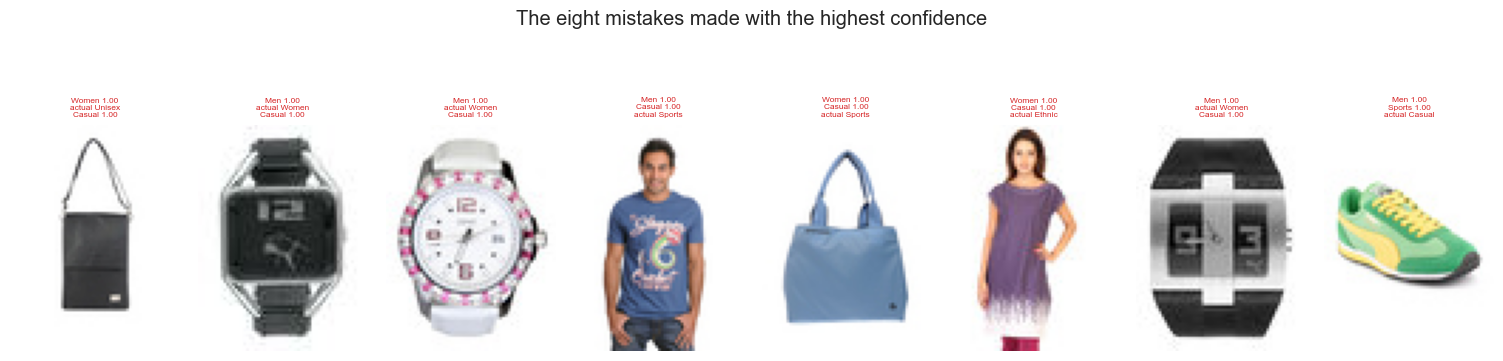

In [81]:
# ============================================
# CELL 25 - Predictions on sample images
# ============================================

# Two panels. A random draw shows typical behaviour; the highest-confidence errors
# show the failure mode. The random draw is sixteen images rather than a handful,
# because at this accuracy a smaller sample is dominated by which items it happened
# to contain.

def prediction_panel(frame, title, columns=8):
    rows = int(np.ceil(len(frame) / columns))
    images, _, _ = next(iter(DataLoader(FashionDataset(frame), batch_size=len(frame))))
    FINAL_MODEL.eval()
    with torch.no_grad():
        logits = FINAL_MODEL(images.to(DEVICE))

    height = 3.0 * rows + 0.8          # reserve space for the figure title
    fig, axes = plt.subplots(rows, columns, figsize=(1.9 * columns, height))
    flat_axes = np.ravel(np.array(axes, dtype=object))
    for position, (ax, (_, row)) in enumerate(zip(flat_axes, frame.iterrows())):
        ax.imshow(np.asarray(IMAGES[row["pos"]])); ax.axis("off")
        lines, correct = [], True
        for target in CONFIG["targets"]:
            probabilities = F.softmax(logits[target][position].float(), dim=0).cpu().numpy()
            index = int(probabilities.argmax())
            hit = class_names[target][index] == row[target + "_label"]
            correct &= hit
            actual = "" if hit else f"\nactual {row[target + '_label']}"
            lines.append(f"{class_names[target][index]} {probabilities[index]:.2f}{actual}")
        ax.set_title("\n".join(lines), fontsize=6,
                     color="tab:green" if correct else "tab:red")
    for ax in flat_axes[len(frame):]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.55 / height))
    plt.show()


set_seed()
prediction_panel(test_df.sample(16, random_state=RANDOM_STATE),
                 "Sixteen test images, drawn at random (red = a mistake)")

# The mistakes made at the highest probability: the cases the model is wrong about
# without any indication that it might be.
confidence = np.minimum(test_predictions["gender"]["prob"].max(axis=1),
                        test_predictions["usage"]["prob"].max(axis=1))
mistaken = ((test_predictions["gender"]["pred"] != test_predictions["gender"]["true"]) |
            (test_predictions["usage"]["pred"] != test_predictions["usage"]["true"]))
ranked = np.argsort(-np.where(mistaken, confidence, -1.0))[:8]
prediction_panel(test_df.iloc[ranked],
                 "The eight mistakes made with the highest confidence")


In [82]:
# ============================================
# CELL 26 - Save
# ============================================

torch.save({
    "state_dict": FINAL_MODEL.state_dict(),
    "model_name": FINAL_NAME,
    "architecture": FINAL_MODEL.settings,
    "num_classes": NUM_CLASSES,
    "class_names": class_names,
    # Ones tell the serving code to take the highest probability directly.
    "class_weights": {t: np.ones(NUM_CLASSES[t]).tolist() for t in CONFIG["targets"]},
    "thresholds_applied": False,
    "channel_mean": CHANNEL_MEAN.tolist(),
    "channel_std": CHANNEL_STD.tolist(),
    "image_size_pil": list(IMAGE_SIZE_PIL),
    "test_metrics": {t: test_summary[t] for t in CONFIG["targets"]},
}, ARTIFACT_DIR / "task3_cnn_model.pt")

verification.to_csv(ARTIFACT_DIR / "design_verification.csv", index=False)
selection.to_csv(ARTIFACT_DIR / "model_selection.csv", index=False)
final.to_csv(ARTIFACT_DIR / "final_test_metrics.csv", index=False)

summary = {
    "final_model": FINAL_NAME,
    "parameters": count_parameters(FINAL_MODEL),
    "noise_floor": round(NOISE_FLOOR, 3),
    "test_gender_accuracy": round(test_summary["gender"]["accuracy"], 2),
    "test_gender_macro_f1": round(test_summary["gender"]["macro_f1"], 2),
    "test_usage_accuracy": round(test_summary["usage"]["accuracy"], 2),
    "test_usage_macro_f1": round(test_summary["usage"]["macro_f1"], 2),
    "test_exact_match": round(test_summary["exact_match"], 2),
    "baseline_gender_accuracy": round(BASELINE["gender"]["accuracy"], 2),
    "baseline_usage_accuracy": round(BASELINE["usage"]["accuracy"], 2),
}
with open(ARTIFACT_DIR / "task3_cnn_summary.json", "w") as handle:
    json.dump(summary, handle, indent=2)

print(json.dumps(summary, indent=2))
print("\nsaved to", ARTIFACT_DIR)
for path in sorted(ARTIFACT_DIR.iterdir()):
    print("  ", path.name)

{
  "final_model": "base",
  "parameters": 4249577,
  "noise_floor": 0.674,
  "test_gender_accuracy": 90.08,
  "test_gender_macro_f1": 77.08,
  "test_usage_accuracy": 91.17,
  "test_usage_macro_f1": 84.28,
  "test_exact_match": 82.09,
  "baseline_gender_accuracy": 54.2,
  "baseline_usage_accuracy": 77.11
}

saved to c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3
   design_verification.csv
   error_analysis.csv
   final_architecture.csv
   final_test_metrics.csv
   imbalance_comparison.csv
   model_selection.csv
   sampler_gender_exposure.csv
   seed_repeats.csv
   task3_cnn_model.pt
   task3_cnn_summary.json


## Summary

A VGG-style convolutional network with early task branching predicts both attributes from a
60×80 image. The design choices — 3×3 kernels, doubling filter counts, ReLU, max pooling and a
flatten-then-dense classifier — are argued from first principles in Part 2, and the three that
were genuinely open to question are tested one factor at a time in Part 5.

Part 6 examined class imbalance and produced a negative result. The diagnosis in Cell 14 showed
that the network was not predicting `Casual` indiscriminately, which rules out the mechanism the
corrections were designed to counter. Balanced batch sampling moved a small amount of macro-F1
from gender to usage, and Cell 18 traces the mechanism: the minority `usage` classes are dominated
by the majority genders, so equalising one attribute makes the rare classes of the other rarer
still. Adding augmentation raised recall on the weakest `usage` class substantially but cost more
macro-F1 than it returned. Neither correction separated itself from the uncorrected configuration
by more than the measurement threshold, so the simpler pipeline was retained; the corrections are
reported because the trade-off they expose is itself the finding.

Comparisons are judged against two sources of uncertainty. The sampling error of the validation
set accounts for its finite size; training each configuration under three random seeds, at a
common epoch cap with early stopping, accounts for the non-determinism of training. Differences
smaller than the larger of the two are reported as ties rather than ranked, and that threshold
governs the tie-break as well as the primary ranking: a margin too small to separate two
configurations cannot be used to choose between them.